# Step 1: Simulate Developer PR Data (Monthly, 3-Tier Teams)

We generate synthetic **monthly** data with known ground truth.

**Key design**: 15 teams across 3 seniority tiers — same team headcount (~20),
but very different seniority mix. This is where hierarchical models shine.

| Tier | Teams | SDE-4 | SDE-3 | SDE-2 | SDE-1 | aSDE |
|------|-------|-------|-------|-------|-------|------|
| Balanced | 1-5 | 2-3 | 4-6 | 4-6 | 2-4 | 4-6 |
| Junior-heavy | 6-10 | 1-2 | 1-3 | 3-5 | 5-7 | 6-8 |
| Mostly-junior | 11-15 | 0-1 | 1 | 2-4 | 6-8 | 8-10 |

**Why this matters for modelling:**

- **Tier 1 (Balanced)**: SDE-4 has 2-3 reps per team — enough signal, m1 and m2 give similar estimates
- **Tier 2 (Junior-heavy)**: SDE-4 has 1-2 reps — sparse, m2 starts borrowing from other teams
- **Tier 3 (Mostly-junior)**: SDE-4 has 0-1 reps — some teams have none at all; m2 borrows the SDE-4 effect from Tiers 1 and 2 plus the team intercept learned from junior devs

See `README.md` for the full model design and notation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
plt.rcParams['figure.dpi'] = 100
plt.style.use('seaborn-v0_8-whitegrid')

## Ground Truth Parameters

In [6]:
# ── Ground truth (all rates are PER MONTH) ────────────────────────────
MU_ORG      = np.log(8)   # grand mean → 8 PRs/month
SIGMA_TEAM  = 0.3
SIGMA_DEV   = 0.4

DESIGNATIONS = ['aSDE', 'SDE-1', 'SDE-2', 'SDE-3', 'SDE-4']
N_MONTHS     = 6

# Designation offsets (log scale)
TRUE_DESIG_OFFSETS = np.array([-0.2, 0.3, 0.2, -0.3, -0.7])

print("Designation  | Offset | Expected PRs/month")
print("-" * 42)
for d, off in zip(DESIGNATIONS, TRUE_DESIG_OFFSETS):
    print(f"  {d:<8}   | {off:>+.1f}   | {np.exp(MU_ORG + off):.1f}")
print(f"\nGrand mean: {np.exp(MU_ORG):.1f} PRs/month")

Designation  | Offset | Expected PRs/month
------------------------------------------
  aSDE       | -0.2   | 6.5
  SDE-1      | +0.3   | 10.8
  SDE-2      | +0.2   | 9.8
  SDE-3      | -0.3   | 5.9
  SDE-4      | -0.7   | 4.0

Grand mean: 8.0 PRs/month


## Define Team Composition per Tier

SDE-4 count is **fixed** per tier to ensure clean comparisons.
Other designations have small random variation (±1) to mimic real orgs.

In [4]:
# ── Team tier definitions ──────────────────────────────────────────────
# SDE-4 now varies within each tier — still shows clear gradient across tiers
# (lo, hi) are inclusive ranges passed to rng.integers(lo, hi+1)
TIERS = {
    'balanced'     : {'teams': range(0, 5),
                      'aSDE': (4,6), 'SDE-1': (2,4), 'SDE-2': (4,6),
                      'SDE-3': (4,6), 'SDE-4': (2,3)},   # 2–3 SDE-4
    'junior_heavy' : {'teams': range(5, 10),
                      'aSDE': (6,8), 'SDE-1': (5,7), 'SDE-2': (3,5),
                      'SDE-3': (1,3), 'SDE-4': (1,2)},   # 1–2 SDE-4
    'mostly_junior': {'teams': range(10,15),
                      'aSDE': (8,10),'SDE-1': (6,8), 'SDE-2': (2,4),
                      'SDE-3': (1,1), 'SDE-4': (0,1)},   # 0–1 SDE-4
}

N_TEAMS = 15

# Build team composition — all designations vary, SDE-4 follows tier range
team_compositions = []
for tier_name, tier in TIERS.items():
    for t in tier['teams']:
        comp = {desig: rng.integers(tier[desig][0], tier[desig][1]+1)
                for desig in ['aSDE','SDE-1','SDE-2','SDE-3','SDE-4']}
        comp['tier']  = tier_name
        comp['total'] = sum(comp[d] for d in DESIGNATIONS)
        team_compositions.append(comp)

# Print team composition
print(f"{'Team':<8} {'Tier':<14} {'aSDE':>5} {'SDE-1':>6} {'SDE-2':>6} {'SDE-3':>6} {'SDE-4':>6} {'Total':>6}")
print("-" * 65)
for i, comp in enumerate(team_compositions):
    print(f"Team-{i+1:<4} {comp['tier']:<14} "
          f"{comp['aSDE']:>5} {comp['SDE-1']:>6} {comp['SDE-2']:>6} "
          f"{comp['SDE-3']:>6} {comp['SDE-4']:>6} {comp['total']:>6}")
total_devs = sum(c['total'] for c in team_compositions)
print(f"\nTotal developers: {total_devs}")
print(f"\nSDE-4 per tier:")
for tier_name in TIERS:
    tier_teams = [c for c in team_compositions if c['tier'] == tier_name]
    sde4_counts = [c['SDE-4'] for c in tier_teams]
    print(f"  {tier_name:<14}: {sde4_counts}  (total={sum(sde4_counts)})")

Team     Tier            aSDE  SDE-1  SDE-2  SDE-3  SDE-4  Total
-----------------------------------------------------------------
Team-1    balanced           4      4      5      5      2     20
Team-2    balanced           6      2      6      4      2     20
Team-3    balanced           5      4      6      6      3     24
Team-4    balanced           6      3      4      6      2     21
Team-5    balanced           5      3      4      6      3     21
Team-6    junior_heavy       7      6      5      2      1     21
Team-7    junior_heavy       7      5      3      2      2     19
Team-8    junior_heavy       6      7      5      1      2     21
Team-9    junior_heavy       6      7      5      2      1     21
Team-10   junior_heavy       8      6      5      3      2     24
Team-11   mostly_junior     10      6      3      1      0     20
Team-12   mostly_junior      9      6      3      1      0     19
Team-13   mostly_junior     10      8      4      1      1     24
Team-14   m

## Build Developer List

In [5]:
rows_dev = []
dev_idx = 0
for team_id, comp in enumerate(team_compositions):
    for desig in DESIGNATIONS:
        for _ in range(comp[desig]):
            rows_dev.append({
                'developer_id': dev_idx,
                'designation' : desig,
                'desig_id'    : DESIGNATIONS.index(desig),
                'team'        : f'Team-{team_id+1}',
                'team_id'     : team_id,
                'tier'        : comp['tier'],
            })
            dev_idx += 1

dev_df = pd.DataFrame(rows_dev)
N_DEVS = len(dev_df)

print(f"Total developers: {N_DEVS}")
print(f"\nDevelopers per tier:")
print(dev_df.groupby('tier')['developer_id'].count())
print(f"\nSDE-4 per tier:")
print(dev_df[dev_df.designation=='SDE-4'].groupby('tier')['developer_id'].count())

Total developers: 316

Developers per tier:
tier
balanced         106
junior_heavy     106
mostly_junior    104
Name: developer_id, dtype: int64

SDE-4 per tier:
tier
balanced         12
junior_heavy      8
mostly_junior     1
Name: developer_id, dtype: int64


## Sample True Random Effects

In [26]:
true_team_effects = rng.normal(0, SIGMA_TEAM, N_TEAMS)
true_dev_noise    = rng.normal(0, SIGMA_DEV,  N_DEVS)

desig_ids_arr = dev_df['desig_id'].values
team_ids_arr  = dev_df['team_id'].values

log_lam_dev = (MU_ORG
               + TRUE_DESIG_OFFSETS[desig_ids_arr]
               + true_team_effects[team_ids_arr]
               + true_dev_noise)
lam_dev = np.exp(log_lam_dev)

dev_df['true_lam']     = lam_dev
dev_df['true_log_lam'] = log_lam_dev

print(f"Lambda range: [{lam_dev.min():.2f}, {lam_dev.max():.2f}] PRs/month")
print(f"Lambda mean : {lam_dev.mean():.2f}")

Lambda range: [1.72, 35.75] PRs/month
Lambda mean : 9.31


## Simulate Monthly Rows

Each developer gets 6 rows (one per month) with `exposure = 1.0`.

In [27]:
rows = []
for _, dev in dev_df.iterrows():
    for month in range(1, N_MONTHS + 1):
        exposure  = 1.0
        lam_month = dev['true_lam'] * exposure
        observed  = rng.poisson(lam_month)
        rows.append({
            'developer_id': dev['developer_id'],
            'month'       : month,
            'designation' : dev['designation'],
            'desig_id'    : dev['desig_id'],
            'team'        : dev['team'],
            'team_id'     : dev['team_id'],
            'tier'        : dev['tier'],
            'true_lam'    : dev['true_lam'],
            'exposure'    : exposure,
            'pr_count'    : observed,
        })

df = pd.DataFrame(rows)
print(f"Shape: {df.shape}  ({N_DEVS} devs × {N_MONTHS} months)")
df.head(8)

Shape: (1896, 10)  (316 devs × 6 months)


,developer_id,month,designation,desig_id,team,team_id,tier,true_lam,exposure,pr_count
0,0,1,aSDE,0,Team-1,0,balanced,10.316876,1.0,13
1,0,2,aSDE,0,Team-1,0,balanced,10.316876,1.0,6
2,0,3,aSDE,0,Team-1,0,balanced,10.316876,1.0,12
3,0,4,aSDE,0,Team-1,0,balanced,10.316876,1.0,11
4,0,5,aSDE,0,Team-1,0,balanced,10.316876,1.0,14
5,0,6,aSDE,0,Team-1,0,balanced,10.316876,1.0,10
6,1,1,aSDE,0,Team-1,0,balanced,11.830116,1.0,10
7,1,2,aSDE,0,Team-1,0,balanced,11.830116,1.0,15


## Visualise Team Composition

This is what makes the simulation interesting: same headcount, different mix.

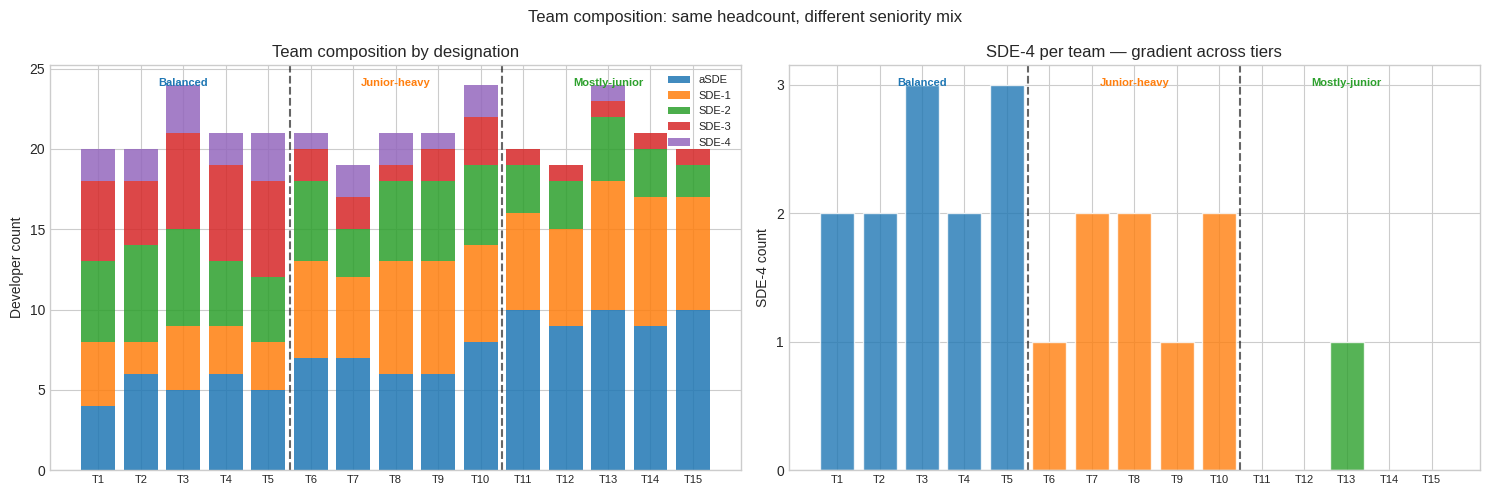

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

TIER_COLORS = {'balanced': 'C0', 'junior_heavy': 'C1', 'mostly_junior': 'C2'}
TIER_LABELS = {'balanced': 'Balanced (T1-5)',
               'junior_heavy': 'Junior-heavy (T6-10)',
               'mostly_junior': 'Mostly-junior (T11-15)'}

def add_tier_separators(ax, y_top, y_label_frac=0.95):
    """Add vertical dividers and tier labels to any team-axis plot."""
    for x in [4.5, 9.5]:
        ax.axvline(x, color='black', lw=1.5, linestyle='--', alpha=0.6)
    ylim = ax.get_ylim()
    y_label = ylim[0] + (ylim[1] - ylim[0]) * y_label_frac
    for x, label, color in [(2, 'Balanced', 'C0'),
                             (7, 'Junior-heavy', 'C1'),
                             (12, 'Mostly-junior', 'C2')]:
        ax.text(x, y_label, label, ha='center', fontsize=8,
                fontweight='bold', color=color)

# Panel 1: Stacked bar — designation mix per team
ax = axes[0]
bottom = np.zeros(N_TEAMS)
for i_d, desig in enumerate(DESIGNATIONS):
    counts = np.array([c[desig] for c in team_compositions])
    ax.bar(range(N_TEAMS), counts, bottom=bottom,
           color=f'C{i_d}', alpha=0.85, label=desig)
    bottom += counts
add_tier_separators(ax, bottom.max())
ax.set_xticks(range(N_TEAMS))
ax.set_xticklabels([f'T{i+1}' for i in range(N_TEAMS)], fontsize=8)
ax.set_ylabel("Developer count")
ax.set_title("Team composition by designation")
ax.legend(fontsize=8, loc='upper right')

# Panel 2: SDE-4 count per team
ax = axes[1]
sde4_counts  = np.array([c['SDE-4'] for c in team_compositions])
tier_col_list = ['C0']*5 + ['C1']*5 + ['C2']*5
ax.bar(range(N_TEAMS), sde4_counts, color=tier_col_list, alpha=0.8, edgecolor='white')
add_tier_separators(ax, sde4_counts.max())
ax.set_xticks(range(N_TEAMS))
ax.set_xticklabels([f'T{i+1}' for i in range(N_TEAMS)], fontsize=8)
ax.set_ylabel("SDE-4 count")
ax.set_title("SDE-4 per team — gradient across tiers")
ax.set_yticks([0, 1, 2, 3])

plt.suptitle("Team composition: same headcount, different seniority mix", fontsize=12)
plt.tight_layout()
plt.show()

## Sanity Check: PR Rates by Tier and Designation

/tmp/ipykernel_845040/3871857373.py:30: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/satishthakur/codebase/data-science/statistics/bayes-bda-rethinking/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


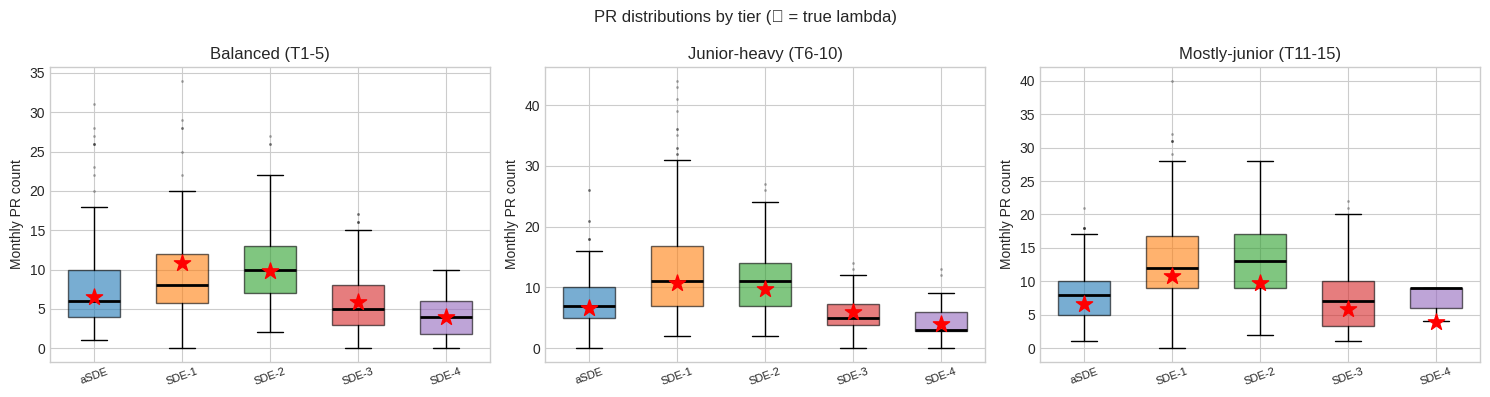

Developer counts by tier and designation:
designation    aSDE  SDE-1  SDE-2  SDE-3  SDE-4
tier                                           
balanced         26     16     25     27     12
junior_heavy     34     31     23     10      8
mostly_junior    48     35     15      5      1


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
tier_names = ['balanced', 'junior_heavy', 'mostly_junior']
tier_labels = ['Balanced (T1-5)', 'Junior-heavy (T6-10)', 'Mostly-junior (T11-15)']

for ax, tier, tlabel in zip(axes, tier_names, tier_labels):
    tier_df = df[df.tier == tier]
    available = [d for d in DESIGNATIONS
                 if tier_df[tier_df.designation==d]['pr_count'].sum() > 0]
    for i, desig in enumerate(available):
        vals = tier_df[tier_df.designation==desig]['pr_count']
        ax.boxplot(vals, positions=[DESIGNATIONS.index(desig)], widths=0.6,
                   patch_artist=True,
                   boxprops=dict(facecolor=f'C{DESIGNATIONS.index(desig)}', alpha=0.6),
                   medianprops=dict(color='black', lw=2),
                   flierprops=dict(marker='.', markersize=2, alpha=0.3))
        ax.scatter(DESIGNATIONS.index(desig),
                   np.exp(MU_ORG + TRUE_DESIG_OFFSETS[DESIGNATIONS.index(desig)]),
                   marker='*', s=150, color='red', zorder=5)
    ax.set_xticks(range(len(DESIGNATIONS)))
    ax.set_xticklabels(DESIGNATIONS, rotation=20, fontsize=8)
    ax.set_ylabel("Monthly PR count")
    ax.set_title(tlabel)
    # Note missing designations
    missing = [d for d in DESIGNATIONS if d not in available]
    if missing:
        ax.text(0.5, 0.02, f"No data: {', '.join(missing)}",
                transform=ax.transAxes, fontsize=8, color='red', ha='center')

plt.suptitle("PR distributions by tier (★ = true lambda)", fontsize=12)
plt.tight_layout()
plt.show()

print("Developer counts by tier and designation:")
pivot = dev_df.groupby(['tier','designation'])['developer_id'].count().unstack(fill_value=0)
pivot = pivot.reindex(columns=DESIGNATIONS)
print(pivot)

## Save to CSV

In [29]:
import os
os.makedirs('../../data', exist_ok=True)
out_path = '../../data/pr_simulated.csv'
df.to_csv(out_path, index=False)
print(f"Saved {len(df)} rows to {out_path}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nKey facts:")
print(f"  Total developers : {N_DEVS}")
print(f"  Teams            : {N_TEAMS} (5 per tier)")
print(f"  SDE-4 in Tier 3  : 0 — these teams borrow entirely from hierarchy")

Saved 1896 rows to ../../data/pr_simulated.csv
Columns: ['developer_id', 'month', 'designation', 'desig_id', 'team', 'team_id', 'tier', 'true_lam', 'exposure', 'pr_count']

Key facts:
  Total developers : 316
  Teams            : 15 (5 per tier)
  SDE-4 in Tier 3  : 0 — these teams borrow entirely from hierarchy


## What We Have

| Column | Description |
|--------|-------------|
| `developer_id` | Integer 0–N |
| `month` | 1–6 |
| `designation` / `desig_id` | Role label + index |
| `team` / `team_id` | Team label + index |
| `tier` | balanced / junior_heavy / mostly_junior |
| `true_lam` | True monthly rate (hidden from model) |
| `exposure` | 1.0 for all rows (all full months) |
| `pr_count` | Observed monthly PR count |

**The `tier` column is key for visualising shrinkage later** —
Tier 3 developers (especially SDE-3/4) will show the strongest pull toward the group mean.

**Next:** `02_eda.ipynb` — verify the data looks as designed.